# PropertyIQ
This project focuses on the benefits and development of AI models to explain in
natural human language the factors that influence a property value, by dividing the
task at hand into two major parts: using XGBoost to predict the value of a
property given properties features (e.g. square meters, number of bedrooms) and
using SHapley Additive exPlanations (SHAP) to generate in human language the
reason behind the model evaluation.
The literature review highlights several benefits of explainable AI in the property
market sector and it emphasises the importance for the end users of human
readable text explaining in detail the factors that affect the model judgement rather
than a score system value where the meaning and reasoning of the model are
hidden to the user.
XGBoost is a tree decision making ML model which may compare to how
humans evaluate the value of a property in the market taking into consideration
different attributes and generating an overall estimate of the property based on the
data provided during the model training. Upon XGBoost prediction, SHAP shows the
features that have increased or decreased the prediction value and the amount.
Finally, it generates an explaining text based on the impact of the different features.


## Dataset

For this project, many datasets have been considered and at the end the a promising candidate has been found: a dataset created by scraping the Zoopla website, which provides us with real-world property data. The dataset can be found in [this repository](https://github.com/luminati-io/Zoopla-dataset-samples).

From a first look at the repository, the dataset seemed promising, given the features it presents.

## Data Exploration

This section will focus on exploring the dataset to understand the data we will be working on during the model training. The dataset features 1000 rows (properties) and 43 columns (attributes).

In [19]:
import pandas as pd

df = pd.read_csv('table.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 1000 rows, 43 columns


### Features

We will explore the dataset feature to understand the possible values we could feed to the model in order to retrieve a metric (i.e. the model will deduct the price of the property given the number of bedrooms, bathrooms, square meter, EPC value, etc.).

In [20]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 43 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   url                               1000 non-null   str    
 1   property_type                     1000 non-null   str    
 2   property_title                    1000 non-null   str    
 3   address                           1000 non-null   str    
 4   google_map_location               1000 non-null   str    
 5   virtual_tour                      0 non-null      float64
 6   street_view                       1000 non-null   str    
 7   url_property                      1000 non-null   str    
 8   currency                          1000 non-null   str    
 9   deposit                           0 non-null      float64
 10  letting_arrangements              0 non-null      float64
 11  breadcrumbs                       1000 non-null   str    
 12  availability      

,url,property_type,property_title,address,google_map_location,virtual_tour,street_view,url_property,currency,deposit,...,energy_performance_certificate,floor_plans,description,price_per_time,property_size,market_stats_last_12_months,market_stats_renta_opportunities,market_stats_recent_sales_nearby,market_stats_rental_activity,uprn
0,https://www.zoopla.co.uk/for-sale/details/6785...,for-sale,2 bed flat for sale,"190, Strand, Westminster, London WC2R","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.5123397,-0.114...",https://www.zoopla.co.uk/for-sale/details/6785...,GBP,NaN,...,"""https://lid.zoocdn.com/u/2400/1800/6be51e8254...","[""https://lid.zoocdn.com/u/2400/1800/1c1b2241f...","[""This stunning two bedroom, two bathroom apar...",NaN,972sq. ft,"{""average_estimated"":""£1,199,567 ↓ -£104,676 (...","£8,346 pcm",NaN,NaN,1.003364e+10
1,https://www.zoopla.co.uk/new-homes/details/679...,new-homes,3 bed flat for sale,"Balmoral Apartments, Praed Street, London W2","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.5188571,-0.170...",https://www.zoopla.co.uk/new-homes/details/679...,GBP,NaN,...,"""https://lid.zoocdn.com/u/2400/1800/fbc3c237fa...","[""https://lid.zoocdn.com/u/2400/1800/0af01d2fc...","[""A 3 bedroom - 2 bathroom (one ensuite) apart...",NaN,1020sq. ft,"{""average_estimated"":""£1,089,293 ↓ -£62,844 (-...","£7,120 pcm","[{""address"":""Flat 6, 85 Westbourne Terrace"",""d...",NaN,NaN
2,https://www.zoopla.co.uk/for-sale/details/6778...,for-sale,1 bed flat for sale,"Old Town, London SW4","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.4655681,-0.141...",https://www.zoopla.co.uk/for-sale/details/6778...,GBP,NaN,...,"""https://lid.zoocdn.com/u/2400/1800/bc898f5748...","[""https://lid.zoocdn.com/u/2400/1800/4e0e0c938...","[""Situated within the 'Metalworks' development...",NaN,618sq. ft,"{""average_estimated"":""£622,130 ↓ -£29,772 (-4....","£2,265 pcm","[{""address"":""Flat 7, Brook House 47-48, Clapha...",NaN,NaN
3,https://www.zoopla.co.uk/for-sale/details/6799...,for-sale,1 bed flat for sale,"Regent Street, London NW10","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.5288208,-0.217...",https://www.zoopla.co.uk/for-sale/details/6799...,GBP,NaN,...,"""https://lid.zoocdn.com/u/2400/1800/6bfe3efd0b...","[""https://lid.zoocdn.com/u/2400/1800/6839e8997...","[""Parkheath is delighted to present for sale t...",NaN,540sq. ft,"{""average_estimated"":""£432,552 ↓ -£39,168 (-8....","£1,701 pcm","[{""address"":""Flat 3-5, Waldo House, Trenmar Ga...",NaN,2.022182e+08
4,https://www.zoopla.co.uk/for-sale/details/6795...,for-sale,1 bed flat for sale,"Cranley Gardens, Wallington SM6","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.3551405,-0.148...",https://www.zoopla.co.uk/for-sale/details/6795...,GBP,NaN,...,"""https://lid.zoocdn.com/u/2400/1800/a2f233aa7d...","[""https://lid.zoocdn.com/u/2400/1800/7c329e600...","[""This well presented 2nd floor retirement apa...",NaN,678sq. ft,"{""average_estimated"":""£308,869 ↓ -£25,644 (-7....","£1,091 pcm","[{""address"":""Flat 35, Marlborough Court, Cranl...",NaN,5.870088e+09


From the `columns` attribute we can see that some columns may not be relevant to the model training like the url pointing to the Zoopla website in the `url` feature, the Google Maps location in the `google_map_location` feature, etc.

### Data formats

From this basic first analysis we can see that the values in the dataset are not fit for model training and will need to be pre-processed. For example, the `service_charge`, appears to be a string (e.g. _£6,686 per year_ as a string rather than a numerical value). There are many features that present this problem, and we can infer that this is due to the original webscraping done to retrieve the different properties.

Also, we can see that from the `info()` method there are many columns that are empty or don't hold a significant value for the model.

## Data Pre-processing

As we have seen in the Data Exploration, we will need to include plenty of pre processing to format and retain the data need to train our prediction model.

### Value formatting

This section will focus on the formatting the data. We will first take care of all the features that hold numerical values but are represent as strings (e.g. the `price` is represented as _"£2,200,000.00"_ and we will transform it into 2200000.00 numerical value).

In [21]:
# Conver the price formatted as "£2,200,000.00" to numerical value 2200000.00
df['price'] = pd.to_numeric(df['price'].astype(str).str.replace('[^0-9.]', '', regex=True), errors='coerce')

# From the property_size only take numbers and cast it.
df['property_size'] = pd.to_numeric(df['property_size'].astype(str).str.replace('[^0-9.]', '', regex=True), errors='coerce')

df['service_charge'] = pd.to_numeric(df['service_charge'].astype(str).str.replace('[^0-9.]', '', regex=True), errors='coerce')

df['time_remaining_on_lease'] = pd.to_numeric(df['time_remaining_on_lease'], errors='coerce')

df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')

df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')

df['receptions'] = pd.to_numeric(df['receptions'], errors='coerce')

# Format the property type (e.g. for-lease or new-homes) to always by lowercase
df['property_type_clean'] = df['property_type'].astype(str).str.lower()

After cleaning the dataset to use actual numbers rather than string, we can remove all rows/properties that are completely empty. This leaves us with **977 meaningful properties**.

In [22]:
df = df.dropna(subset=['price', 'property_size'])

df.shape[0]

977

## Feature Engineering

Even though the dataset contains a lot of features that hold meaningful values for the model training, we have decided to create new features which will help the model to score even higher. For example a property that has postcode _SW12 CDE_ is in London while another property with postcode _M13 9XX_ is in Manchester. Given that they are located in different cities the prices will be completely different regardless of the similarity in the properties.

We use a UK postcode-prefix-to-region lookup to map postcodes to their respective cities/regions. For example, postcodes starting with SW, SE, N, NW, E, EC, W, WC are all mapped to London. M postcodes map to Manchester, B to Birmingham, etc. This creates one boolean column per region (e.g., `is_london`, `is_manchester`, `is_birmingham`) rather than treating each raw postcode prefix as a separate category.

In [23]:
POSTCODE_TO_REGION = {
    # London postcodes
    'E': 'london', 'EC': 'london', 'N': 'london', 'NW': 'london',
    'SE': 'london', 'SW': 'london', 'W': 'london', 'WC': 'london',
    'BR': 'london', 'CR': 'london', 'DA': 'london', 'EN': 'london',
    'HA': 'london', 'IG': 'london', 'KT': 'london', 'RM': 'london',
    'SM': 'london', 'TW': 'london', 'UB': 'london', 'WD': 'london',
    # Manchester
    'M': 'manchester', 'OL': 'manchester', 'SK': 'manchester', 'BL': 'manchester',
    'WN': 'manchester',
    # Birmingham
    'B': 'birmingham', 'WS': 'birmingham', 'WV': 'birmingham', 'DY': 'birmingham',
    # Liverpool
    'L': 'liverpool', 'CH': 'liverpool',
    # Leeds
    'LS': 'leeds', 'BD': 'leeds', 'HX': 'leeds', 'HD': 'leeds', 'WF': 'leeds',
    # Sheffield
    'S': 'sheffield', 'DN': 'sheffield',
    # Bristol
    'BS': 'bristol',
    # Edinburgh
    'EH': 'edinburgh',
    # Glasgow
    'G': 'glasgow', 'PA': 'glasgow',
    # Cardiff
    'CF': 'cardiff',
    # Newcastle
    'NE': 'newcastle', 'SR': 'newcastle', 'DH': 'newcastle',
    # Nottingham
    'NG': 'nottingham',
    # Leicester
    'LE': 'leicester',
    # Southampton
    'SO': 'southampton',
    # Portsmouth
    'PO': 'portsmouth',
    # Brighton
    'BN': 'brighton',
    # Cambridge
    'CB': 'cambridge',
    # Oxford
    'OX': 'oxford',
    # Reading
    'RG': 'reading',
    # Coventry
    'CV': 'coventry',
    # Plymouth
    'PL': 'plymouth',
    # Aberdeen
    'AB': 'aberdeen',
    # Belfast
    'BT': 'belfast',
}

# All UK regions we track (one boolean column per region)
UK_REGIONS = ['london', 'manchester', 'birmingham', 'liverpool', 'leeds', 'sheffield',
              'bristol', 'edinburgh', 'glasgow', 'cardiff', 'newcastle', 'nottingham',
              'leicester', 'southampton', 'portsmouth', 'brighton', 'cambridge',
              'oxford', 'reading', 'coventry', 'plymouth', 'aberdeen', 'belfast']

def extract_postcode_prefix(address):
    import re
    if pd.isna(address):
        return None
    # Match UK postcode patterns at end of address
    match = re.search(r'([A-Z]{1,2})\d', str(address).upper())
    if match:
        return match.group(1)
    return None

def get_region_from_postcode(prefix):
    if prefix is None:
        return 'other'
    # Try full prefix first (e.g., 'SW'), then first letter (e.g., 'S')
    if prefix in POSTCODE_TO_REGION:
        return POSTCODE_TO_REGION[prefix]
    if len(prefix) > 1 and prefix[0] in POSTCODE_TO_REGION:
        return POSTCODE_TO_REGION[prefix[0]]
    return 'other'

# Extract postcode prefix and map to region
df['postcode_prefix'] = df['address'].apply(extract_postcode_prefix)
df['region'] = df['postcode_prefix'].apply(get_region_from_postcode)

# Create boolean columns for each region (is_london, is_manchester, etc.)
for region in UK_REGIONS:
    df[f'is_{region}'] = (df['region'] == region).astype(int)

# Drop intermediate columns
df = df.drop(columns=['postcode_prefix', 'region'])

print(f"Region columns created: {[f'is_{r}' for r in UK_REGIONS]}")

Region columns created: ['is_london', 'is_manchester', 'is_birmingham', 'is_liverpool', 'is_leeds', 'is_sheffield', 'is_bristol', 'is_edinburgh', 'is_glasgow', 'is_cardiff', 'is_newcastle', 'is_nottingham', 'is_leicester', 'is_southampton', 'is_portsmouth', 'is_brighton', 'is_cambridge', 'is_oxford', 'is_reading', 'is_coventry', 'is_plymouth', 'is_aberdeen', 'is_belfast']


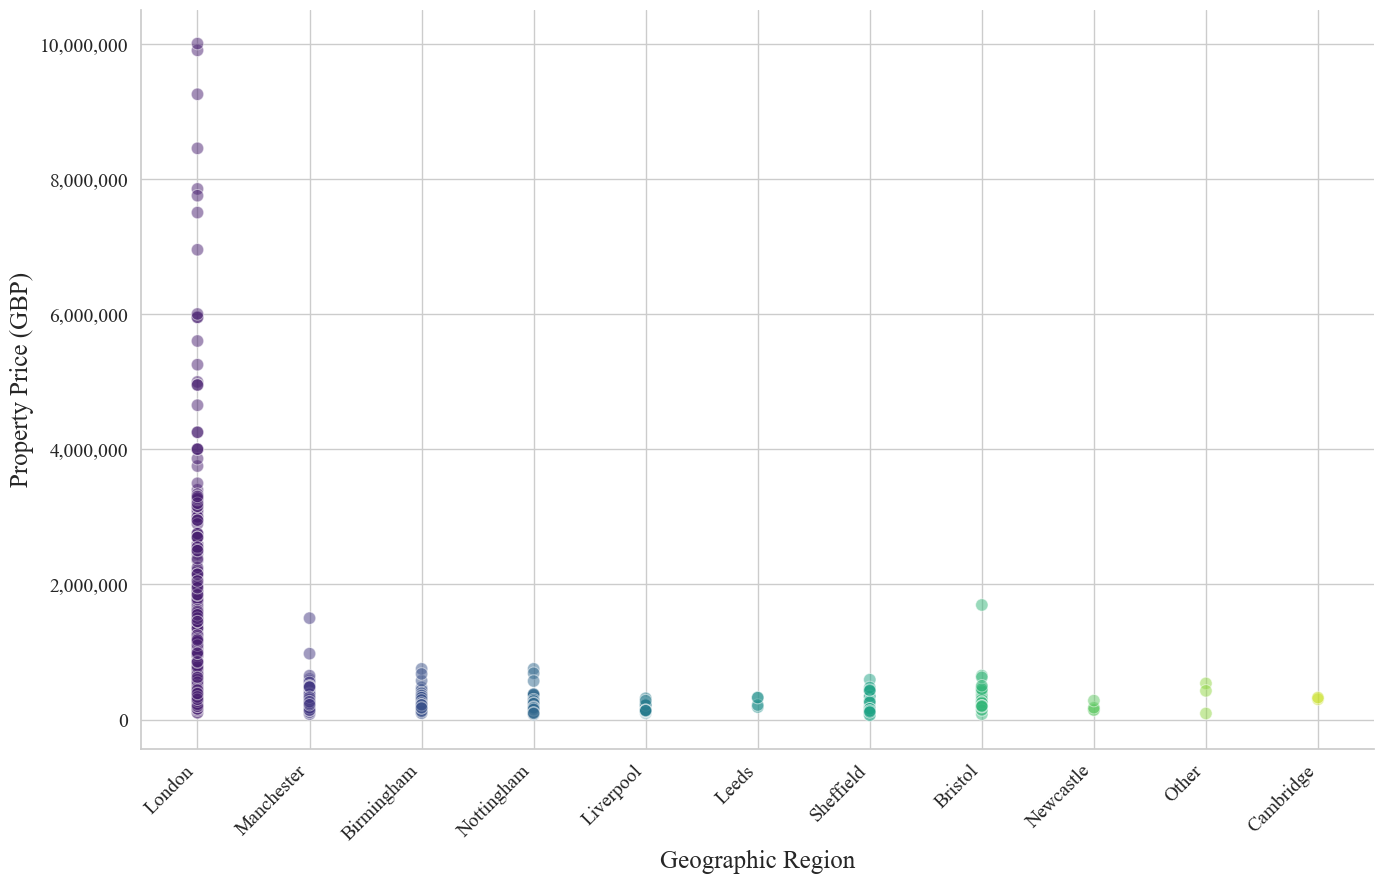

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

sns.set_theme(style="whitegrid")

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'serif']

# Re-apply region label logic
def get_region_label(row):
    for region in UK_REGIONS:
        if row[f'is_{region}'] == 1:
            return region.capitalize()
    return 'Other'

df_plot = df.copy()
df_plot['location_group'] = df_plot.apply(get_region_label, axis=1)


plt.figure(figsize=(14, 9))
ax = sns.scatterplot(
    data=df_plot,
    x='location_group',
    y='price',
    alpha=0.5,
    s=80,
    palette='viridis',
    hue='location_group',
    legend=False
)

# Formatting for y-axis
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Increased font sizes for paper publication
plt.xlabel('Geographic Region', fontsize=18)
plt.ylabel('Property Price (GBP)', fontsize=18)

# Refine x-axis and y-axis ticks font size
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)

# Remove top and right spines
sns.despine()

plt.tight_layout()
plt.show()

Another useful feature is **price per square meter**, calculated by dividing price by property size. On their own, price and size each tell only half the story, while combining them into a single ratio gives the model a much stronger signal of value.

For example, two properties both listed at £60,000 look identical by price alone. But if one is 100 m<superscript>2</supercript> (£600/m<superscript>2</supercript>) and the other is 30 m<superscript>2</supercript> (£2,000/m<superscript>2</supercript>), price per square meter immediately reveals that the first offers far better value,exactly the kind of signal that drives real market pricing.

In [25]:
df['price_per_sqft'] = df['price'] / df['property_size']

Training on the raw price treats every error in absolute terms, so a £10,000 miss counts the same whether the property is worth £50,000 or £5,000,000. Training on `log1p(price)` instead converts errors into relative terms, meaning the model is penalised by percentage rather than pounds. This also compresses the skewed distribution of prices, reducing the influence of a few very expensive outliers.

For example, a £10,000 error on a £50,000 flat (20% off) hurts the log-trained model far more than the same error on a £2M mansion (0.5% off), which better reflects how pricing accuracy actually matters in the real market.

In [26]:
import numpy as np

df['log_price'] = np.log1p(df['price'])

### Feature Selection

We have cleaned the dataset and engineered meaningful features for model training. The region-based boolean columns (is_london, is_manchester, etc.) provide clear geographic signal. We also one-hot encode property_type_clean to distinguish between property listing types.

In [27]:
# Columns to keep for model training from the original dataset
base_features = ['bedrooms', 'bathrooms', 'receptions', 'property_size', 'time_remaining_on_lease', 'service_charge', 'price_per_sqft']

# Region columns (is_london, is_manchester, etc.)
region_features = [f'is_{region}' for region in UK_REGIONS]

# One-hot encode property_type_clean only (region is already boolean columns)
df = pd.get_dummies(df, columns=['property_type_clean'], drop_first=True)

df.head()


,url,property_type,property_title,address,google_map_location,virtual_tour,street_view,url_property,currency,deposit,...,is_cambridge,is_oxford,is_reading,is_coventry,is_plymouth,is_aberdeen,is_belfast,price_per_sqft,log_price,property_type_clean_new-homes
0,https://www.zoopla.co.uk/for-sale/details/6785...,for-sale,2 bed flat for sale,"190, Strand, Westminster, London WC2R","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.5123397,-0.114...",https://www.zoopla.co.uk/for-sale/details/6785...,GBP,NaN,...,0,0,0,0,0,0,0,2263.374486,14.603968,False
1,https://www.zoopla.co.uk/new-homes/details/679...,new-homes,3 bed flat for sale,"Balmoral Apartments, Praed Street, London W2","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.5188571,-0.170...",https://www.zoopla.co.uk/new-homes/details/679...,GBP,NaN,...,0,0,0,0,0,0,0,1470.588235,14.220976,True
2,https://www.zoopla.co.uk/for-sale/details/6778...,for-sale,1 bed flat for sale,"Old Town, London SW4","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.4655681,-0.141...",https://www.zoopla.co.uk/for-sale/details/6778...,GBP,NaN,...,0,0,0,0,0,0,0,1011.326861,13.345509,False
3,https://www.zoopla.co.uk/for-sale/details/6799...,for-sale,1 bed flat for sale,"Regent Street, London NW10","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.5288208,-0.217...",https://www.zoopla.co.uk/for-sale/details/6799...,GBP,NaN,...,0,0,0,0,0,0,0,1064.814815,13.262127,False
4,https://www.zoopla.co.uk/for-sale/details/6795...,for-sale,1 bed flat for sale,"Cranley Gardens, Wallington SM6","""https://maps.googleapis.com/maps/api/staticma...",NaN,"https://www.google.com/maps/@51.3551405,-0.148...",https://www.zoopla.co.uk/for-sale/details/6795...,GBP,NaN,...,0,0,0,0,0,0,0,265.412979,12.100440,False


In [28]:
# All columns to keep for the training of the model (original + engineered features)
# Includes base features, region booleans (is_london, etc.), and property type dummies
feature_cols = base_features + region_features + [col for col in df.columns if col.startswith('property_type_clean_')]
print(f"Total features: {len(feature_cols)}")
print(f"Features: {feature_cols}")


Total features: 31
Features: ['bedrooms', 'bathrooms', 'receptions', 'property_size', 'time_remaining_on_lease', 'service_charge', 'price_per_sqft', 'is_london', 'is_manchester', 'is_birmingham', 'is_liverpool', 'is_leeds', 'is_sheffield', 'is_bristol', 'is_edinburgh', 'is_glasgow', 'is_cardiff', 'is_newcastle', 'is_nottingham', 'is_leicester', 'is_southampton', 'is_portsmouth', 'is_brighton', 'is_cambridge', 'is_oxford', 'is_reading', 'is_coventry', 'is_plymouth', 'is_aberdeen', 'is_belfast', 'property_type_clean_new-homes']


### Model Training

Now that the data has been processed into a machine understandable language, we can train the model.

### Train and Test

The first step is to separate the columns in the dataset that will be used as features to train the model (i.e. bedrooms, bathrooms, reception, service charge, etc.) and the feature containing the prediction value (the $\log(price)$).

In [29]:
X = df[feature_cols]
print("Training features: ", X.columns.tolist())
y = df['log_price']
print("Predicting features:", y.name)

Training features:  ['bedrooms', 'bathrooms', 'receptions', 'property_size', 'time_remaining_on_lease', 'service_charge', 'price_per_sqft', 'is_london', 'is_manchester', 'is_birmingham', 'is_liverpool', 'is_leeds', 'is_sheffield', 'is_bristol', 'is_edinburgh', 'is_glasgow', 'is_cardiff', 'is_newcastle', 'is_nottingham', 'is_leicester', 'is_southampton', 'is_portsmouth', 'is_brighton', 'is_cambridge', 'is_oxford', 'is_reading', 'is_coventry', 'is_plymouth', 'is_aberdeen', 'is_belfast', 'property_type_clean_new-homes']
Predicting features: log_price


Given the dataset is 977 properties we are going to implement the standard 80-20 split, which means 80% of the data will be used to train the model, while the remaining 20% will be used to test the accuracy of the model is.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

After splitting the dataset we create an empty model with parameter (e.g. `n_estimators`) which will be trained on the dataset. We decided to go for `random_state=42` in order to retain reproducibility (i.e. every time we run the model, it is trained the same way and we get always get the same result instead of a small variance).

In [31]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mae'
)

After creating the empty model, it is time to train the model with the processed data. We specify `X_train`, which are the features used for training and `y_train`, which is basically the `log_price`. The model will run and given the training columns it will understand how to predict the $\log(price)$.

In [32]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Evaluation

After training the model on 80% of the data, we are going to assess how good is the model by checking against the remaining 20% of the dataset.

This is the standard approach: the model _studies_ on 80% of the data and learns from it how to predict the `log(price)` and we have 20% of the data that the model has never seen that we can test it against.

In [33]:
# The model predicted log(price) for testing
y_pred_log = model.predict(X_test)

# Convert the log(price) back to be the price.
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

Now that we have the result of testing the model against the 20% of the dataset that he never saw, we will print metrics that evaluate the model.

In [34]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"R2 Score : {r2_score(y_test_real, y_pred):.4f}")
print(f"MAE: £{mean_absolute_error(y_test_real, y_pred):,.0f}")

R2 Score : 0.9557
MAE: £56,451


The result shows that the model has **95.57%** _accuracy_, and a Mean Absolute Error (MAE) of £56,451. This means the model has been trained well and it produces highly accurate predictions, very close to the actual value of the property.

## Save the model

As the model performs well, we will save this model into a `.pkl` file which will be used in the `PropertyIQ` web app.

How the model works is we pass values for a single property (i.e. bathrooms, bedroom, service charge, etc.) and the model will predict a good estimate of the value of the property.

In [35]:
import pickle

with open('model1_price_predictor.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)